In [ ]:
%pip install --upgrade --force-reinstall pandas numpy scanpy

: 

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib as mpl

In [2]:
!tree ./data/

./data/
├── Ath_1h.h5ad
├── Ath_3h.h5ad
├── Ath_6h.h5ad
└── hashes.txt

1 directory, 4 files


In [3]:
## 1. Load required data
adata = sc.read_h5ad("data/Ath_3h.h5ad")

In [4]:
# Print the object summary to check your metadata slots
adata

AnnData object with n_obs × n_vars = 146597 × 30620
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'RNA_snn_res.0.8', 'seurat_clusters', 'group_clusters', 'celltype', 'group_celltype', 'metacell_grouping', 'pos_regulon_score', 'neg_regulon_score', 'group'
    var: 'gene_names'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', None

In [5]:
adata.uns

{'celltype_colors': array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
        '#e377c2', '#7f7f7f', '#bcbd22'], dtype=object)}

In [6]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,RNA_snn_res.0.8,seurat_clusters,group_clusters,celltype,group_celltype,metacell_grouping,pos_regulon_score,neg_regulon_score,group
AAACCCACAAACTCTG-4,Col0_AA_3h_1,1795,1239,0.109349,2,2,Col0_AA_2,Mesophyll,Col0_AA_Mesophyll,Col0_AA_Mesophyll,0.259188,0.156890,Col0_AA
AAACCCACAGGTTCCG-4,Col0_AA_3h_1,1901,1319,0.000000,1,1,Col0_AA_1,Unknown,Col0_AA_Unknown,Col0_AA_Unknown,0.208924,0.168168,Col0_AA
AAACGAAAGGTCGAGT-4,Col0_AA_3h_1,1532,1084,0.064516,1,1,Col0_AA_1,Unknown,Col0_AA_Unknown,Col0_AA_Unknown,0.190459,0.185816,Col0_AA
AAACGAACAATTGTGC-4,Col0_AA_3h_1,2474,1587,0.079239,0,0,Col0_AA_0,Mesophyll,Col0_AA_Mesophyll,Col0_AA_Mesophyll,0.172868,0.169749,Col0_AA
AAACGAACACCTGCGA-4,Col0_AA_3h_1,1769,1179,0.000000,1,1,Col0_AA_1,Unknown,Col0_AA_Unknown,Col0_AA_Unknown,0.206682,0.150179,Col0_AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCCATCCGGTG-6,Col0_AA_3h_3,771,652,0.000000,4,4,Col0_AA_4,Epidermis,Col0_AA_Epidermis,Col0_AA_Epidermis,0.186157,0.135644,Col0_AA
TTTCGATGTTGCCAAT-6,Col0_AA_3h_3,1682,1181,0.058480,5,5,Col0_AA_5,Epidermis,Col0_AA_Epidermis,Col0_AA_Epidermis,0.220209,0.146811,Col0_AA
TTTGGTTGTTGACGGA-6,Col0_AA_3h_3,1921,1254,0.051680,4,4,Col0_AA_4,Epidermis,Col0_AA_Epidermis,Col0_AA_Epidermis,0.248350,0.146587,Col0_AA
ACACGCGCAAGGCCTC-23,nac17_AA_3h_2,2406,1592,0.000000,4,4,nac17_AA_4,Epidermis,nac17_AA_Epidermis,nac17_AA_Epidermis,0.280512,0.164266,nac17_AA


In [7]:
adata.obs['celltype'].unique()

['Mesophyll', 'Unknown', 'G2/M phase', 'Phloem parenchyma and Xylem', 'Epidermis', 'Bundle sheath', 'Guard cell', 'Trichome', 'Companion cell']
Categories (9, str): ['Bundle sheath', 'Companion cell', 'Epidermis', 'G2/M phase', ..., 'Mesophyll', 'Phloem parenchyma and Xylem', 'Trichome', 'Unknown']

In [8]:
adata.obs['seurat_clusters'].unique()



array([ 2,  1,  0,  3, 14,  7,  6, 11, 15, 20,  8,  5, 13,  4, 10, 18, 19,
       12,  9, 17, 16, 21])

In [9]:
sorted(adata.obs['seurat_clusters'].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21)]

In [9]:
adata.var

# Save to CSV
adata.var.to_csv("umap_genes.csv")

In [ ]:
# Save to CSV
adata.var.to_csv("adata_var.csv")

In [16]:
## 3. FacetDotPlot Custom Function
def facet_dot_plot(
    adata,
    features,
    group_by="celltype",
    split_by="group",
    dot_scale=8,
    viridis_option="viridis"
):
    if isinstance(features, str):
        features = [features]
        
    expr_matrix = adata[:, features].to_df()
    metadata = adata.obs[[group_by, split_by]].copy()
    df = pd.concat([expr_matrix, metadata], axis=1)
    
    df_long = df.melt(
        id_vars=[group_by, split_by], 
        value_vars=features, 
        var_name="gene", 
        value_name="expr"
    )
    
    plot_data = df_long.groupby([group_by, split_by, "gene"]).agg(
        avg_exp=("expr", "mean"),
        pct_exp=("expr", lambda x: (x > 0).mean() * 100)
    ).reset_index()
    
    groups = plot_data[split_by].unique()
    ncol = min(4, len(groups))
    
    g = sns.FacetGrid(plot_data, col=split_by, col_wrap=ncol, margin_titles=True, height=4, aspect=1)
    
    def scatter_mapping(data, **kwargs):
        scatter = plt.scatter(
            x=data[group_by],
            y=data["gene"],
            s=data["pct_exp"] * (dot_scale ** 2 / 100), 
            c=data["avg_exp"],
            cmap=viridis_option,
            edgecolors="none"
        )
        return scatter

    g.map_dataframe(scatter_mapping)
    
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid(False) 
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_visible(True)
        # Add padding between top/bottom borders and first/last genes
        ax.margins(y=0.1)
            
    path_coll = g.axes[0].collections[0] if g.axes[0].collections else None
    if path_coll:
        cbar_ax = g.figure.add_axes([1.02, 0.3, 0.02, 0.4])
        plt.colorbar(path_coll, cax=cbar_ax, label="Average\nexpression")
    
    # Add size legend for dot sizes (percent expressed)
    size_pct_values = [25, 50, 75, 100]
    size_handles = []
    for pct in size_pct_values:
        handle = plt.scatter(
            [], [], 
            s=pct * (dot_scale ** 2 / 100),
            c='gray', edgecolors='none', alpha=0.7
        )
        size_handles.append(handle)
    
    g.figure.legend(
        size_handles,
        [f"{p}%" for p in size_pct_values],
        title="Percent\nexpressed",
        loc='center left',
        bbox_to_anchor=(1.02, 0.12),
        frameon=True,
        scatterpoints=1,
        handletextpad=1.5
    )
        
    g.set_axis_labels("", "")
    g.set_titles(col_template="{col_name}")
    
    plt.tight_layout()
    plt.show()
    return g

/tmp/ipykernel_4098/558503048.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_4098/558503048.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_4098/558503048.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_4098/558503048.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_4098/558503048.py:87: UserWarning: This figure in

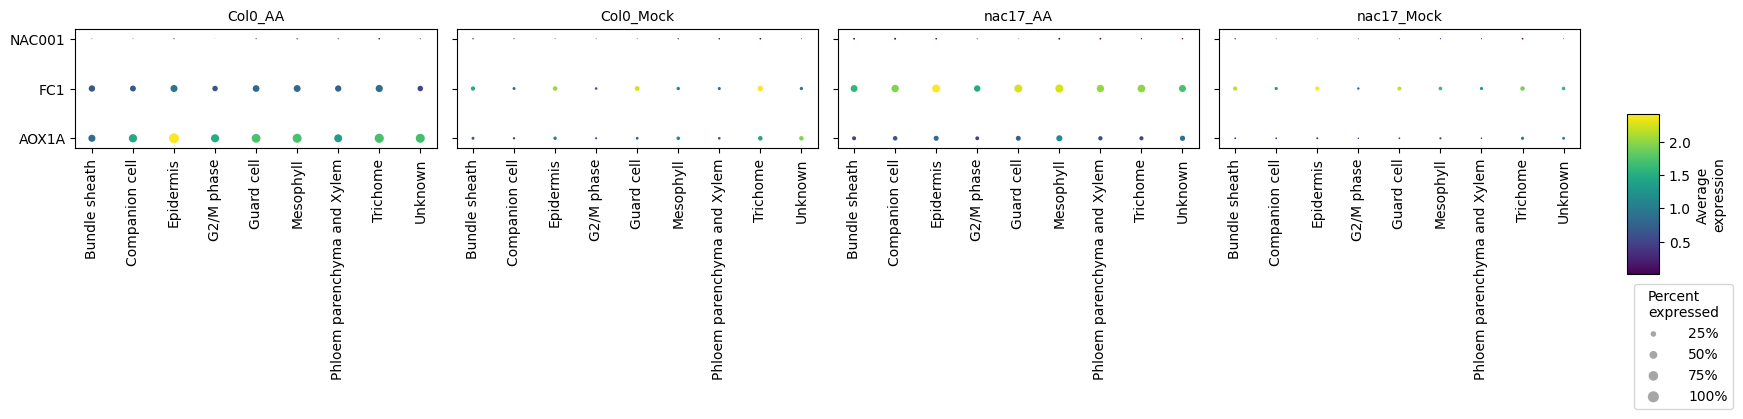

In [17]:
# 4. Generate the plot
facet_dot_plot(
    adata=adata,
    features=["FC1", "AOX1A", "NAC001"],
    group_by="celltype",
    split_by="group",
    viridis_option="viridis",
    dot_scale=8
)

/tmp/ipykernel_4564/792513688.py:18: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  expr_values = adata_subset.obs_vector("FDH").astype(float)


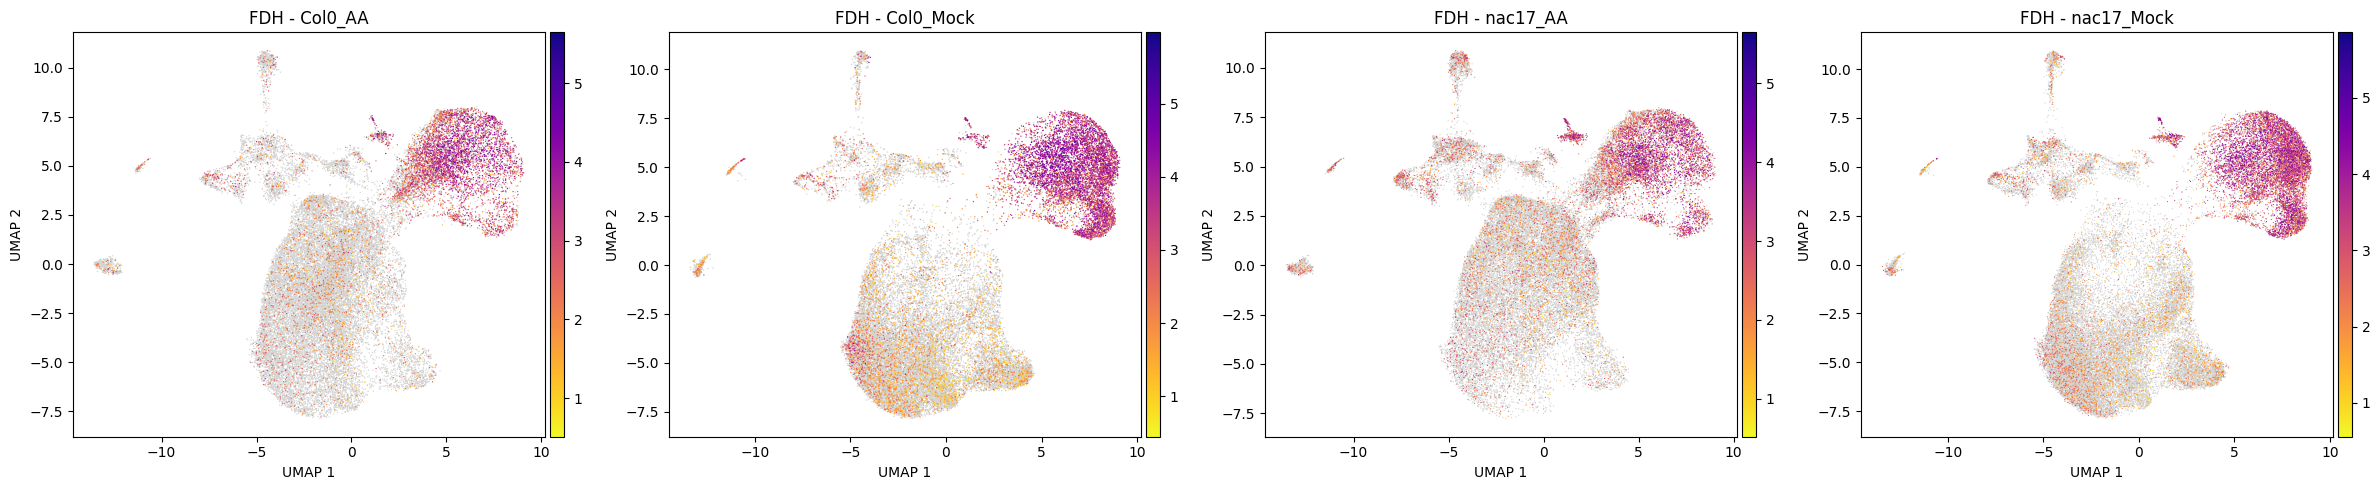

In [4]:
# Set your R-equivalent Cutoffs
na_cutoff = 1e-09
na_color = "lightgray"

# Get the unique groups present in your metadata
unique_groups = adata.obs['group'].unique()
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 5))

if len(unique_groups) == 1:
    axes = [axes]

for i, group_name in enumerate(unique_groups):
    # Subset data for the specific group
    adata_subset = adata[adata.obs['group'] == group_name].copy()
    
    # 1. Pull the gene expression values for 'FDH'
    # Scanpy stores expression in .obs_vector(). We convert it to a float array.
    expr_values = adata_subset.obs_vector("FDH").astype(float)
    
    # 2. Apply the R cutoff: Mask any values less than or equal to 1e-09 as NaN
    expr_values[expr_values <= na_cutoff] = np.nan
    
    # 3. Add this modified custom column temporarily back into the subset metadata
    adata_subset.obs["FDH_masked"] = expr_values

    # 4. Create and configure the reversed plasma colormap to handle NaNs (NA values)
    # We fetch 'plasma_r' and tell it to color any 'bad' (NaN) values as lightgray
    current_cmap = mpl.colormaps["plasma_r"].copy()
    current_cmap.set_bad(color=na_color)

    # 5. Plot using Scanpy with our masked color data and custom colormap
    sc.pl.umap(
        adata_subset,
        color="FDH_masked",
        ax=axes[i],
        show=False,
        title=f"FDH - {group_name}",
        cmap=current_cmap,
        frameon=True
    )
    
    # --- FORCE NUMBERS AND TICK MARKS TO RE-APPEAR ---
    axes[i].xaxis.set_major_locator(ticker.AutoLocator())
    axes[i].yaxis.set_major_locator(ticker.AutoLocator())
    axes[i].tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=True)
    axes[i].set_xlabel("UMAP 1")
    axes[i].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

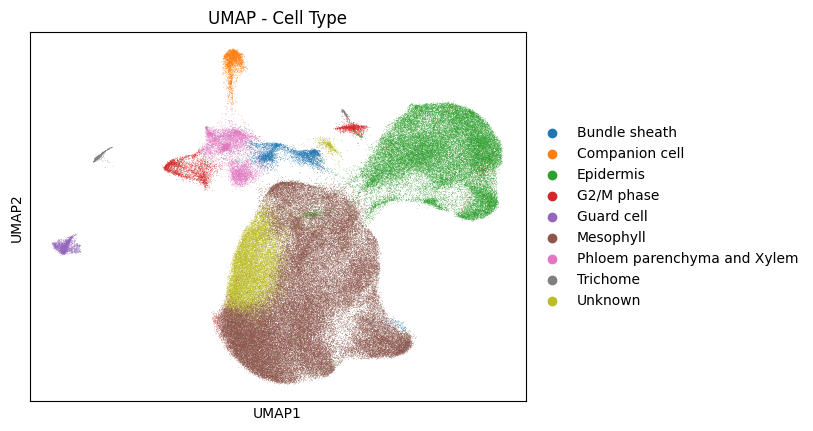

In [5]:
# UMAP colored by cell type
sc.pl.umap(
    adata,
    color="celltype",
    title="UMAP - Cell Type",
    frameon=True,
    legend_loc="right margin"
)


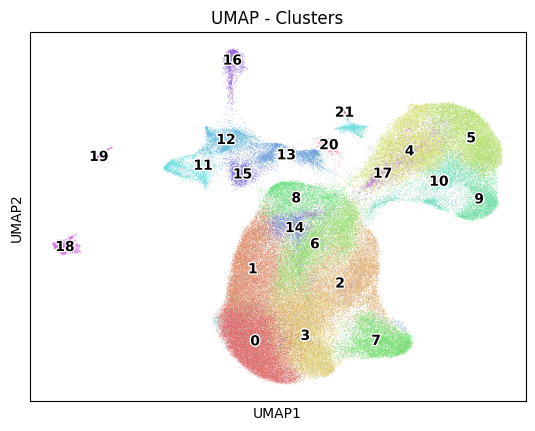

In [11]:
import colorsys
import matplotlib.colors as mcolors

def ggplot_hue_palette(n):
    """Replicates ggplot2's hue_pal()(n) in Python."""
    hues = [i / n for i in range(n)]
    # ggplot2 uses h=c(0, 360)+15, l=65, c=100
    rgb_colors = [colorsys.hls_to_rgb(h, 0.65, 0.65) for h in hues]
    return rgb_colors

# UMAP colored by cluster with cluster labels overlaid
adata.obs["seurat_clusters"] = adata.obs["seurat_clusters"].astype("category")

n_clusters = len(adata.obs["seurat_clusters"].cat.categories)
my_palette = ggplot_hue_palette(n_clusters)

sc.pl.umap(
    adata,
    color="seurat_clusters",
    title="UMAP - Clusters",
    frameon=True,
    legend_loc="on data",
    legend_fontsize=10,
    legend_fontoutline=2,
    palette=my_palette
)
